# IET SMP Assignment: Variational Autoencoders (VAE) with MNIST

**Total Marks: 20**

**Instructions:**
- Read each question carefully.
- Write the required code and brief explanations in the notebook cells provided.
- Run all code cells after completing the assignment.
- Keep your answers clear, concise, and well-organized.

### Assignment Overview
This notebook is structured as a short practical assignment on Variational Autoencoders using the MNIST dataset. You will define the model, train it, and generate new handwritten digit samples.

### Mark Distribution
- Concept of VAE and latent space: **3 marks**
- Encoder design and reparameterization trick: **5 marks**
- VAE loss function: **4 marks**
- Training setup and loop: **5 marks**
- Generating new digits and interpretation: **3 marks**


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


### Question 1: VAE Concept, Encoder Design, and Reparameterization Trick [8 marks]

Explain the purpose of a Variational Autoencoder and how its latent space differs from that of a standard autoencoder.

Then describe how the VAE encoder produces the latent distribution parameters and why the reparameterization trick is required for backpropagation.

In your answer, include:
- the role of mean ($\mu$)
- the role of log-variance ($\log(\sigma^2)$)
- how $z = \mu + \sigma \odot \epsilon$ supports training

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # TODO: define the encoder layers here
        self.fc1 = nn.Linear(input_dim, hidden_dim)

        # TODO: define the latent mean and log-variance layers here
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # TODO: define the decoder layers here
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        # TODO: flatten the input and pass it through the encoder
         x = x.view(-1, 784)
         h1 = F.relu(self.fc1(x))

        # TODO: return the latent mean and log-variance
         mu = self.fc_mu(h1)
         logvar = self.fc_logvar(h1)

         return mu, logvar

         raise NotImplementedError("Complete the encode method")

    def reparameterize(self, mu, logvar):
        # TODO: sample epsilon and apply the reparameterization trick
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std


        raise NotImplementedError("Complete the reparameterize method")

    def decode(self, z):
        # TODO: map the latent vector back to the image space
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

        raise NotImplementedError("Complete the decode method")

    def forward(self, x):
        # TODO: connect encode -> reparameterize -> decode
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

        raise NotImplementedError("Complete the forward method")


# TODO: instantiate the model after completing the class
model = VAE().to(device)
print("VAE model initialized")


VAE model initialized


A Variational Autoencoder (VAE) is a type of neural network used to generate new data. A normal autoencoder compresses data into one fixed latent vector. A VAE is different because it compresses data into a probability distribution instead of a single point.

The encoder produces two values:

1. Mean (μ): the center of the distribution
2. Log-variance (logvar): the spread or uncertainty of the distribution

The latent vector is created using:

z = μ + σ * ε

where:

σ = exp(0.5 × logvar)
ε is random noise sampled from a normal distribution

This process is called the reparameterization trick. The reparameterization trick allows the model to perform random sampling while still allowing gradients to flow during training. Because of this, the VAE learns a smooth and continuous latent space. This helps the model generate new data and create meaningful interpolations between samples.

### Question 2: VAE Loss Function [4 mark]

Write the loss function for the VAE and briefly explain the purpose of each term.

Your response should include:
- reconstruction loss using binary cross entropy
- KL divergence and why it is needed

In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    x = x.view(-1, 784)
    # TODO: compute the reconstruction loss
    recon_loss = F.binary_cross_entropy(
        recon_x,
        x,
        reduction='sum'
    )
    # TODO: compute the KL divergence term
    kl_div = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    # TODO: return the total VAE loss
    return recon_loss + kl_div
    raise NotImplementedError("Complete the VAE loss function")


The VAE loss has two parts.

1. Reconstruction Loss:
This measures how well the decoder rebuilds the original image.
2. KL Divergence Loss:
This forces the latent space to stay close to a normal distribution N(0,1).

This makes the latent space smooth and organized. Because of this, the VAE can generate new and meaningful samples.

### Question 3: Training the VAE on MNIST [5 marks]

Complete the training setup for the MNIST dataset and train the model for the required number of epochs.

Include:
- dataset loading and preprocessing
- optimizer selection
- forward pass, loss calculation, and parameter updates

In [ ]:
# Hyperparameters
# TODO: choose appropriate batch size, number of epochs, and learning rate
batch_size = 128
epochs = 15
learning_rate = 1e-3

# Data transformation and loading
# TODO: add any preprocessing needed for MNIST


transform = transforms.ToTensor()
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# TODO: create the optimizer after the model has been defined
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training Loop
model.train()

for epoch in range(epochs):

    total_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):

        # Move data to device
        data = data.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        recon_batch, mu, logvar = model(data)

        # Compute loss
        loss = vae_loss(recon_batch, data, mu, logvar)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}")


# TODO: complete the training loop
# Hint: move data to device, run the model, compute the loss, backpropagate, and update weights


Epoch [1/15] Loss: 105.0772
Epoch [2/15] Loss: 104.7957
Epoch [3/15] Loss: 104.6700
Epoch [4/15] Loss: 104.4591
Epoch [5/15] Loss: 104.3861
Epoch [6/15] Loss: 104.1425
Epoch [7/15] Loss: 104.0938
Epoch [8/15] Loss: 103.9032
Epoch [9/15] Loss: 103.8499
Epoch [10/15] Loss: 103.7297
Epoch [11/15] Loss: 103.6152
Epoch [12/15] Loss: 103.4803
Epoch [13/15] Loss: 103.4699
Epoch [14/15] Loss: 103.3099
Epoch [15/15] Loss: 103.2671


### Question 4: Generating New Digits [3 mark]

Use the trained decoder to generate new handwritten digits from random latent vectors.

Then briefly comment on the quality of the generated samples and what this suggests about the learned latent space.

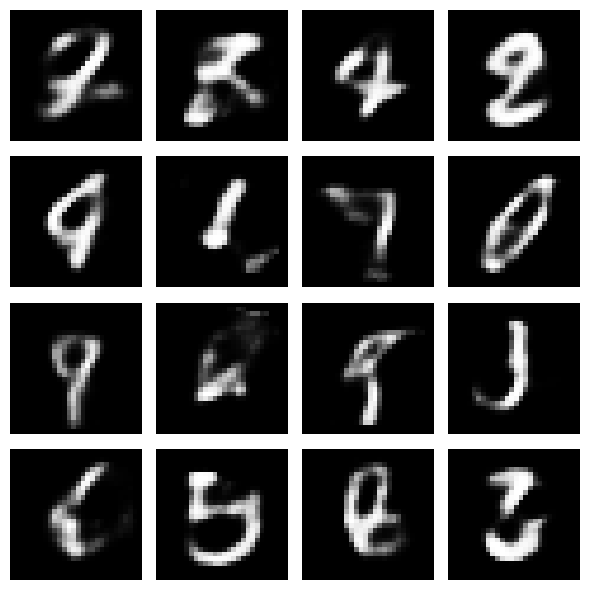

In [ ]:
# TODO: write code to sample from the latent space using the trained decoder
# TODO: visualize the generated digits
# Set model to evaluation mode
model.eval()

with torch.no_grad():

    # Sample random latent vectors
    z = torch.randn(16, 20).to(device)

    # Generate images using decoder
    generated = model.decode(z)

    # Reshape images
    generated = generated.view(-1, 1, 28, 28)

    # Move to CPU for visualization
    generated = generated.cpu()

# Plot generated digits
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].squeeze(), cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()



After training, the VAE can generate handwritten digit images. The generated digits usually look realistic. Some images may look blurry. This happens because the VAE focuses on learning probabilities instead of creating perfectly sharp images. The model learns a smooth and organized latent space. Nearby points in the latent space produce similar digit styles.